In [5]:
import pandas as pd
import kagglehub
import os

# Download dataset terbaru dari Kaggle
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

# Cek isi folder untuk menemukan nama file CSV-nya
print(os.listdir(path))

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final
['Sample - Superstore.csv']


In [6]:
# Gabungkan path folder dengan nama file CSV
csv_file_path = os.path.join(path, 'Sample - Superstore.csv')

# Load CSV ke DataFrame (encoding='latin1' karena dataset ini pakai karakter non-UTF8)
df = pd.read_csv(csv_file_path, encoding='latin1')

# Tampilkan 5 baris pertama untuk verifikasi
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


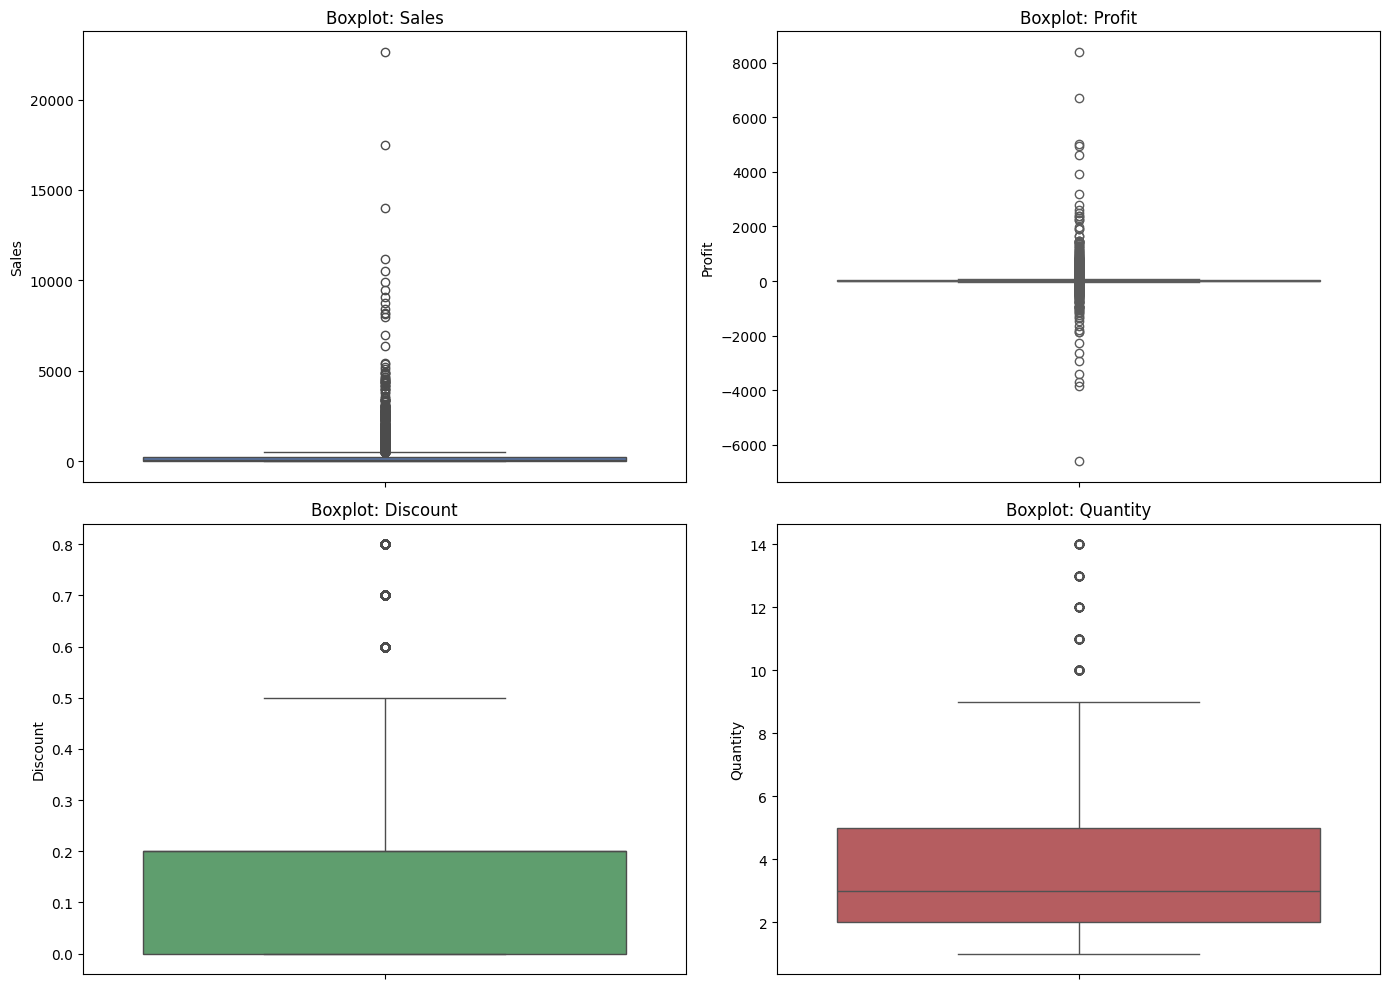

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=df['Sales'], ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Boxplot: Sales')

sns.boxplot(y=df['Profit'], ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Boxplot: Profit')

sns.boxplot(y=df['Discount'], ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Boxplot: Discount')

sns.boxplot(y=df['Quantity'], ax=axes[1,1], color='#C44E52')
axes[1,1].set_title('Boxplot: Quantity')

plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=150)
plt.show()

In [8]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in ['Sales', 'Profit', 'Discount', 'Quantity']:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"\n--- {col} ---")
    print(f"Batas normal: {lb:.2f} sampai {ub:.2f}")
    print(f"Jumlah outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% dari total data)")


--- Sales ---
Batas normal: -271.71 sampai 498.93
Jumlah outlier: 1167 (11.68% dari total data)

--- Profit ---
Batas normal: -39.72 sampai 70.82
Jumlah outlier: 1881 (18.82% dari total data)

--- Discount ---
Batas normal: -0.30 sampai 0.50
Jumlah outlier: 856 (8.57% dari total data)

--- Quantity ---
Batas normal: -2.50 sampai 9.50
Jumlah outlier: 170 (1.70% dari total data)


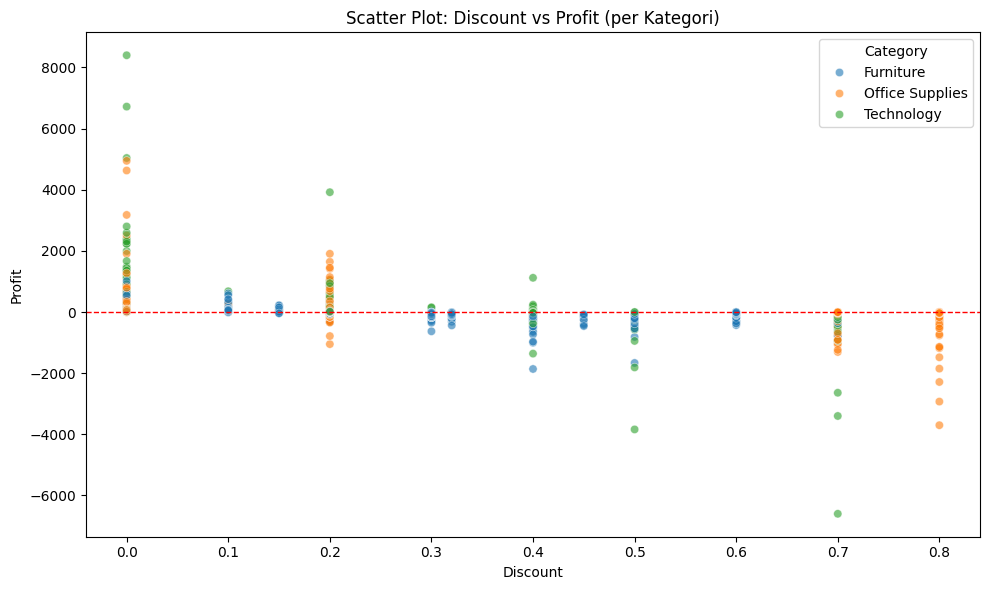

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Scatter Plot: Discount vs Profit (per Kategori)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('scatter_discount_profit.png', dpi=150)
plt.show()

In [10]:
outliers_profit, _, _ = detect_outliers_iqr(df, 'Profit')
high_discount_outliers = outliers_profit[outliers_profit['Discount'] >= 0.5]

print(f"\nInsight:")
print(f"- Dari {len(outliers_profit)} outlier pada Profit, {len(high_discount_outliers)} di antaranya ({len(high_discount_outliers)/len(outliers_profit)*100:.1f}%) memiliki diskon >= 50%.")
print(f"- Ini menunjukkan diskon besar adalah penyebab utama outlier kerugian (profit sangat negatif).")


Insight:
- Dari 1881 outlier pada Profit, 265 di antaranya (14.1%) memiliki diskon >= 50%.
- Ini menunjukkan diskon besar adalah penyebab utama outlier kerugian (profit sangat negatif).


In [11]:
top_loss_outliers = df.nsmallest(10, 'Profit')[['Order ID', 'Category', 'Sub-Category', 'Sales', 'Discount', 'Profit', 'Region']]
print("\n10 Order dengan Kerugian Terbesar:")
display(top_loss_outliers)


10 Order dengan Kerugian Terbesar:


,Order ID,Category,Sub-Category,Sales,Discount,Profit,Region
7772,CA-2016-108196,Technology,Machines,4499.985,0.7,-6599.9780,East
683,US-2017-168116,Technology,Machines,7999.980,0.5,-3839.9904,South
9774,CA-2014-169019,Office Supplies,Binders,2177.584,0.8,-3701.8928,Central
3011,CA-2017-134845,Technology,Machines,2549.985,0.7,-3399.9800,West
4991,US-2017-122714,Office Supplies,Binders,1889.990,0.8,-2929.4845,Central
3151,CA-2015-147830,Technology,Machines,1799.994,0.7,-2639.9912,East
5310,CA-2017-131254,Office Supplies,Binders,1525.188,0.8,-2287.7820,Central
9639,CA-2015-116638,Furniture,Tables,4297.644,0.4,-1862.3124,South
1199,CA-2016-130946,Office Supplies,Binders,1088.792,0.8,-1850.9464,Central
2697,CA-2014-145317,Technology,Machines,22638.480,0.5,-1811.0784,South


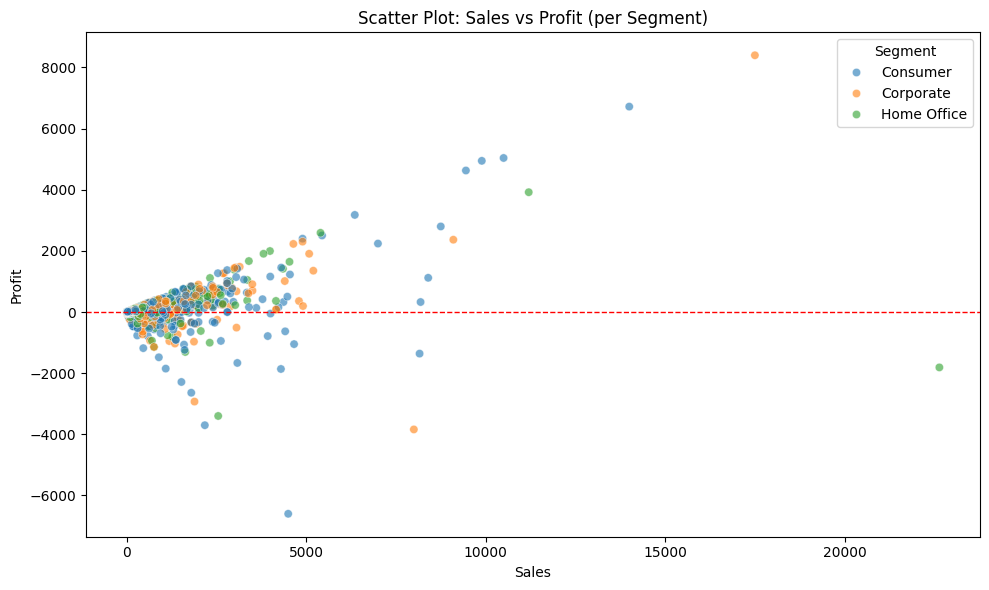

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Segment', alpha=0.6)
plt.title('Scatter Plot: Sales vs Profit (per Segment)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('scatter_sales_profit.png', dpi=150)
plt.show()